# EvolBA — Evolutionary Boundary Attack on CIFAR-10

**Model:** ResNet-56 pretrained on CIFAR-10 from [`chenyaofo/pytorch-cifar-models`](https://github.com/chenyaofo/pytorch-cifar-models) (~93.4% test accuracy).  
This is a widely cited, publicly available model — no training required.

**Setting:** Hard-Label Black-Box (HL-BB) — attacker receives only the predicted label.

**Method:** EvolBA in three phases:

| Phase | What happens |
|---|---|
| **1 — Init** | Random perturbations until misclassification |
| **2 — Boundary** | Binary search between clean and adversarial to land on the decision boundary |
| **3 — Refine** | CMA-ES initialized at the boundary minimises `‖x_adv − x‖₂` while staying adversarial |

> **Note:** Run this notebook with the **Python 3.12** kernel (`AppData/Local/Programs/Python/Python312`). The project `.venv` on the Desktop is blocked by Windows Application Control and cannot load compiled extensions like matplotlib.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import cma

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# CIFAR-10 channel statistics (used for model normalisation inside the oracle)
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010], dtype=np.float32)

print(f'Device : {DEVICE}')
print(f'CMA-ES : {cma.__version__}')

Device : cpu
CMA-ES : 4.4.4


## 2. Pretrained Model

**ResNet-56** from `chenyaofo/pytorch-cifar-models` — a well-known public benchmark collection with models pretrained specifically on CIFAR-10/100.  
No fine-tuning needed; weights are downloaded automatically and cached in `~/.cache/torch/hub`.

| Model | Params | CIFAR-10 accuracy |
|---|---|---|
| ResNet-20 | 0.27 M | 91.7% |
| **ResNet-56** | **0.86 M** | **93.4%** |
| ResNet-110 | 1.73 M | 93.6% |
| VGG-16-BN | 14.7 M | 93.6% |
| MobileNetV2 | 2.24 M | 94.4% |

In [2]:
model = torch.hub.load(
    'chenyaofo/pytorch-cifar-models',
    'cifar10_resnet56',
    pretrained=True,
    trust_repo=True,
    verbose=False,
)
model = model.to(DEVICE)
model.eval()
print('ResNet-56 loaded.')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet-56 loaded.
Parameters: 855,770


## 3. Dataset

100%|██████████| 170M/170M [00:43<00:00, 3.96MB/s]   
c:\Users\tomma\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Test samples: 10,000


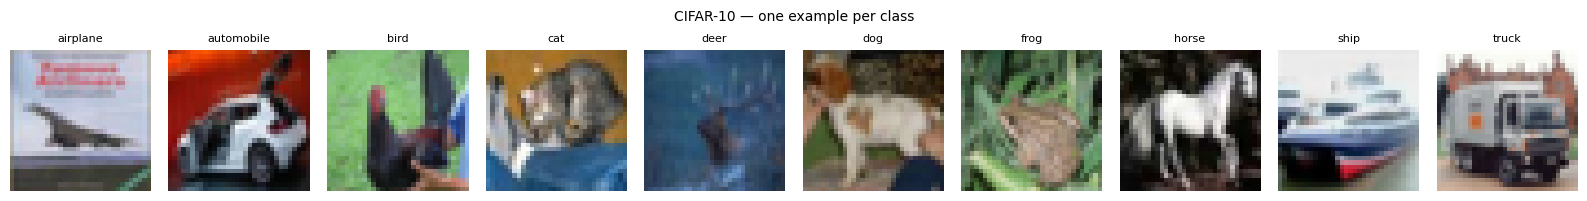

In [3]:
# Load raw pixels in [0,1] — normalisation happens inside the oracle, not here.
# This way the attack always works in interpretable pixel space.
transform = transforms.ToTensor()

test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

print(f'Test samples: {len(test_ds):,}')

# Preview
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
shown = {}
for img, label in test_ds:
    if label not in shown:
        shown[label] = img.numpy().transpose(1, 2, 0)   # CHW → HWC
    if len(shown) == 10:
        break
for i in range(10):
    axes[i].imshow(shown[i])
    axes[i].set_title(CLASS_NAMES[i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 — one example per class', fontsize=10)
plt.tight_layout()
plt.show()

### 3.1 Verify model accuracy

In [4]:
norm_mean = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1).to(DEVICE)
norm_std  = torch.tensor(CIFAR_STD ).view(1, 3, 1, 1).to(DEVICE)

correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        imgs_n = (imgs - norm_mean) / norm_std   # normalise
        preds  = model(imgs_n).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += len(labels)

print(f'ResNet-56 test accuracy on CIFAR-10: {correct/total*100:.2f}%')

ResNet-56 test accuracy on CIFAR-10: 94.37%


## 4. Collect correctly-classified samples

In [5]:
def collect_correct(model, dataset, n=200):
    """
    Returns up to n (image_hwc, true_label) pairs the model classifies correctly.
    Images are stored as (H, W, C) = (32, 32, 3) float32 numpy arrays in [0, 1].
    """
    model.eval()
    samples = []
    loader  = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    with torch.no_grad():
        for imgs, labels in loader:
            imgs_n  = (imgs.to(DEVICE) - norm_mean) / norm_std
            preds   = model(imgs_n).argmax(1).cpu()
            correct = (preds == labels).nonzero(as_tuple=True)[0]
            for i in correct:
                hwc = imgs[i].numpy().transpose(1, 2, 0)  # CHW → HWC
                samples.append((hwc, labels[i].item()))
                if len(samples) >= n:
                    return samples
    return samples

SAMPLES = collect_correct(model, test_ds, n=200)
print(f'{len(SAMPLES)} correctly-classified test samples ready.')
print(f'Image shape: {SAMPLES[0][0].shape}  dtype: {SAMPLES[0][0].dtype}')

200 correctly-classified test samples ready.
Image shape: (32, 32, 3)  dtype: float32


## 5. EvolBA Implementation

### 5.1 HL-BB oracle

Accepts an `(H, W, C)` numpy image in `[0, 1]`, applies CIFAR-10 normalisation internally, and returns only the predicted class index.

In [6]:
def oracle(model, image_hwc):
    """
    Hard-label black-box query.
    image_hwc: (32, 32, 3) float32 in [0, 1]
    Returns predicted class index.
    """
    # HWC → CHW, normalise, add batch dim
    t = torch.from_numpy(image_hwc.transpose(2, 0, 1)).float().to(DEVICE)
    t = (t - norm_mean.squeeze(0)) / norm_std.squeeze(0)
    t = t.unsqueeze(0)
    with torch.no_grad():
        return model(t).argmax(1).item()

### 5.2 Phase 1 — Find an initial adversarial example

In [7]:
def find_initial_adversarial(model, image_hwc, true_label, query_counter, max_attempts=500):
    """
    Add Gaussian noise with increasing scale until the model misclassifies.
    Returns the first adversarial found (possibly far from original).
    """
    rng = np.random.default_rng(SEED)
    for scale in np.linspace(0.05, 2.0, max_attempts):
        noise = rng.standard_normal(image_hwc.shape).astype(np.float32) * scale
        adv   = np.clip(image_hwc + noise, 0.0, 1.0)
        query_counter[0] += 1
        if oracle(model, adv) != true_label:
            return adv
    return None

### 5.3 Phase 2 — Binary search to the decision boundary

In [8]:
def binary_search_boundary(model, image_hwc, adv_hwc, true_label, query_counter, n_steps=15):
    """
    Binary search on [image_hwc, adv_hwc] for the decision boundary.

    Invariant:
        lo  →  correctly classified  (clean side)
        hi  →  misclassified         (adversarial side)

    Returns hi at convergence: closest adversarial point to x.
    """
    lo = image_hwc.copy()
    hi = adv_hwc.copy()

    for _ in range(n_steps):
        mid = (lo + hi) / 2.0
        query_counter[0] += 1
        if oracle(model, mid) != true_label:
            hi = mid
        else:
            lo = mid

    return hi

### 5.4 Phase 3 — CMA-ES boundary refinement

Identical logic to the Fashion-MNIST version but operating in a 3072-dimensional space (32×32×3) instead of 784 (28×28×1).

In [9]:
PENALTY = 20.0   # must exceed any realistic ||x_adv - x||_2 for 32×32×3 images in [0,1]

def cmaes_refine(model, image_hwc, true_label, boundary_adv,
                 query_counter, max_queries, gen_l2_history):
    """
    Phase 3: CMA-ES refinement starting from the boundary adversarial.
    Operates on the flattened (H*W*C,) perturbation vector.

    Returns: best_adv (H,W,C), best_l2 (float)
    """
    delta_init = (boundary_adv - image_hwc).flatten().astype(np.float64)
    n          = delta_init.size       # 3072
    init_l2    = float(np.linalg.norm(delta_init))

    best_adv = boundary_adv.copy()
    best_l2  = init_l2

    sigma0 = max(0.3 * init_l2 / np.sqrt(n), 1e-3)

    remaining = max_queries - query_counter[0]
    if remaining <= 0:
        return best_adv, best_l2

    es = cma.CMAEvolutionStrategy(
        delta_init,
        sigma0,
        {'maxfevals': remaining, 'verbose': -9, 'seed': SEED}
    )

    while not es.stop() and query_counter[0] < max_queries:
        candidates = es.ask()
        fitnesses  = []

        for c in candidates:
            x_cand = np.clip(
                image_hwc + c.reshape(image_hwc.shape).astype(np.float32),
                0.0, 1.0
            )
            query_counter[0] += 1
            pred = oracle(model, x_cand)
            l2   = float(np.linalg.norm(x_cand - image_hwc))

            if pred != true_label:
                if l2 < best_l2:
                    best_l2  = l2
                    best_adv = x_cand.copy()
                fitnesses.append(l2)
            else:
                fitnesses.append(PENALTY + l2)

        es.tell(candidates, fitnesses)
        gen_l2_history.append(best_l2)

    return best_adv, best_l2

### 5.5 Full EvolBA pipeline

In [10]:
def evolba(model, image_hwc, true_label, max_queries=3000, bs_steps=15):
    """
    EvolBA: Evolutionary Boundary Attack (hard-label black-box).

    Args:
        image_hwc   : (32, 32, 3) float32 in [0, 1], correctly classified
        true_label  : ground-truth class index
        max_queries : total oracle query budget across all three phases
        bs_steps    : binary-search iterations in Phase 2

    Returns dict with keys:
        success, queries, best_adv, best_l2, init_l2, l2_reduction, gen_l2_history
    """
    qc = [0]

    # Phase 1
    init_adv = find_initial_adversarial(model, image_hwc, true_label, qc)
    if init_adv is None:
        return {'success': False, 'queries': qc[0]}

    # Phase 2
    boundary_adv = binary_search_boundary(
        model, image_hwc, init_adv, true_label, qc, n_steps=bs_steps
    )
    init_l2 = float(np.linalg.norm(boundary_adv - image_hwc))

    # Phase 3
    gen_l2_history = []
    best_adv, best_l2 = cmaes_refine(
        model, image_hwc, true_label, boundary_adv, qc, max_queries, gen_l2_history
    )

    reduction = (init_l2 - best_l2) / init_l2 * 100 if init_l2 > 0 else 0.0

    return {
        'success'        : True,
        'queries'        : qc[0],
        'best_adv'       : best_adv,
        'best_l2'        : best_l2,
        'init_l2'        : init_l2,
        'l2_reduction'   : reduction,
        'gen_l2_history' : gen_l2_history,
    }

## 6. Single-image demo

In [11]:
MAX_Q    = 3000
BS_STEPS = 15

demo_hwc, demo_label = SAMPLES[0]

print(f'True class : {CLASS_NAMES[demo_label]}')
r_demo = evolba(model, demo_hwc, demo_label, max_queries=MAX_Q, bs_steps=BS_STEPS)

print(f"Queries used                    : {r_demo['queries']}")
print(f"L2 after binary search (Phase 2): {r_demo['init_l2']:.4f}")
print(f"L2 after CMA-ES (Phase 3)       : {r_demo['best_l2']:.4f}")
print(f"L2 reduction                    : {r_demo['l2_reduction']:.1f}%")
adv_label = oracle(model, r_demo['best_adv'])
print(f"Model now predicts              : {CLASS_NAMES[adv_label]}")

True class : cat
Queries used                    : 3012
L2 after binary search (Phase 2): 2.3519
L2 after CMA-ES (Phase 3)       : 2.1515
L2 reduction                    : 8.5%
Model now predicts              : frog


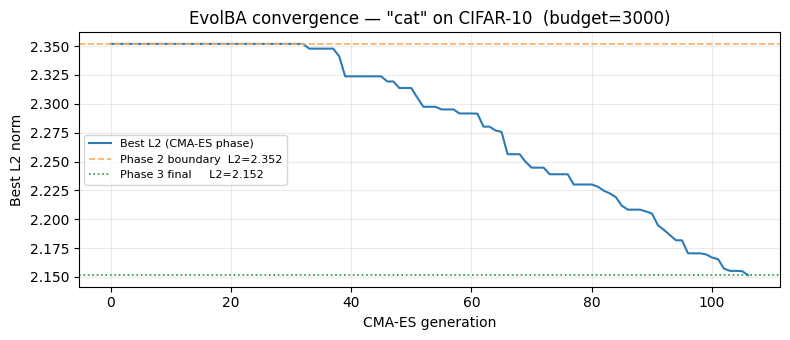

In [12]:
# Convergence curve
gen_hist = r_demo['gen_l2_history']

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(gen_hist, color='#2c7bb6', linewidth=1.5, label='Best L2 (CMA-ES phase)')
ax.axhline(r_demo['init_l2'], color='#fdae61', linewidth=1.2, linestyle='--',
           label=f"Phase 2 boundary  L2={r_demo['init_l2']:.3f}")
ax.axhline(r_demo['best_l2'], color='#1a9641', linewidth=1.2, linestyle=':',
           label=f"Phase 3 final     L2={r_demo['best_l2']:.3f}")
ax.set_xlabel('CMA-ES generation')
ax.set_ylabel('Best L2 norm')
ax.set_title(f'EvolBA convergence — "{CLASS_NAMES[demo_label]}" on CIFAR-10  (budget={MAX_Q})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('cifar10_convergence_demo.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Visual inspection

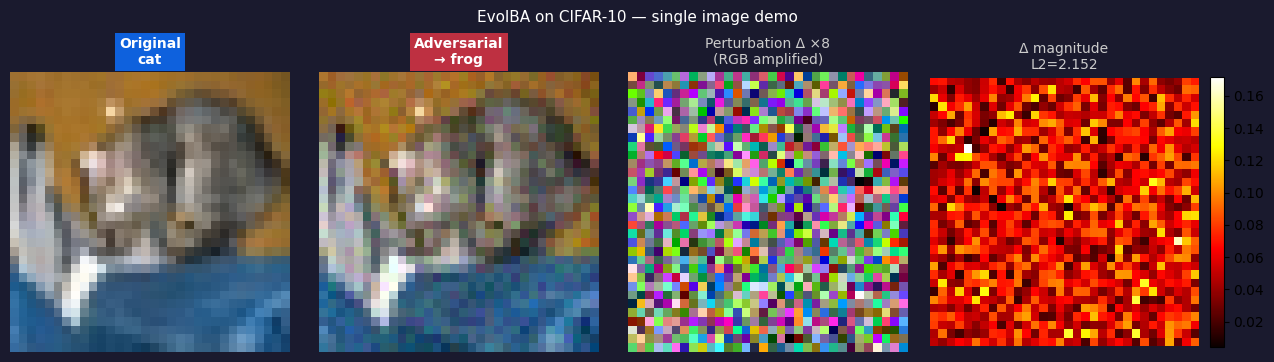

In [13]:
adv_hwc   = r_demo['best_adv']
delta_hwc = adv_hwc - demo_hwc
adv_label = oracle(model, adv_hwc)

# Per-pixel perturbation magnitude (L2 across RGB channels)
delta_mag = np.linalg.norm(delta_hwc, axis=2)   # (32, 32)

# Amplified delta clipped to [0,1] for RGB display
delta_vis = np.clip(delta_hwc * 8 + 0.5, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
fig.patch.set_facecolor('#1a1a2e')

axes[0].imshow(np.clip(demo_hwc, 0, 1))
axes[0].set_title(f'Original\n{CLASS_NAMES[demo_label]}',
                  color='white', fontsize=10, fontweight='bold',
                  bbox=dict(facecolor='#0d6efd', alpha=0.85, pad=3, edgecolor='none'))
axes[0].axis('off')

axes[1].imshow(np.clip(adv_hwc, 0, 1))
axes[1].set_title(f'Adversarial\n\u2192 {CLASS_NAMES[adv_label]}',
                  color='white', fontsize=10, fontweight='bold',
                  bbox=dict(facecolor='#dc3545', alpha=0.85, pad=3, edgecolor='none'))
axes[1].axis('off')

axes[2].imshow(delta_vis)
axes[2].set_title('Perturbation \u0394 \u00d78\n(RGB amplified)',
                  color='#cccccc', fontsize=10)
axes[2].axis('off')

im = axes[3].imshow(delta_mag, cmap='hot')
axes[3].set_title(f'\u0394 magnitude\nL2={r_demo["best_l2"]:.3f}',
                  color='#cccccc', fontsize=10)
axes[3].axis('off')
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle('EvolBA on CIFAR-10 — single image demo', color='white', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('cifar10_demo_single.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 7. Batch evaluation

In [14]:
N_EVAL  = 50
results = []

for i, (img_hwc, label) in enumerate(SAMPLES[:N_EVAL]):
    r = evolba(model, img_hwc, label, max_queries=MAX_Q, bs_steps=BS_STEPS)
    r['true_label'] = label
    r['image_hwc']  = img_hwc
    if r['success']:
        r['adv_label'] = oracle(model, r['best_adv'])
    results.append(r)
    if (i + 1) % 10 == 0:
        succ   = [x for x in results if x['success']]
        avg_l2 = np.mean([x['best_l2'] for x in succ]) if succ else float('nan')
        print(f'[{i+1:3d}/{N_EVAL}]  success={len(succ)/len(results)*100:.0f}%  avg_L2={avg_l2:.4f}')

successes = [r for r in results if r['success']]
print(f'\n── Final summary ──────────────────────────────────────')
print(f'Success rate       : {len(successes)/N_EVAL*100:.1f}%  ({len(successes)}/{N_EVAL})')
print(f'Avg queries        : {np.mean([r["queries"]       for r in successes]):.0f}')
print(f'Avg L2 (boundary)  : {np.mean([r["init_l2"]      for r in successes]):.4f}')
print(f'Avg L2 (final)     : {np.mean([r["best_l2"]      for r in successes]):.4f}')
print(f'Avg L2 reduction   : {np.mean([r["l2_reduction"] for r in successes]):.1f}%')

[ 10/50]  success=100%  avg_L2=3.1447
[ 20/50]  success=100%  avg_L2=3.0264
[ 30/50]  success=100%  avg_L2=3.1065
[ 40/50]  success=100%  avg_L2=3.0628
[ 50/50]  success=100%  avg_L2=3.2475

── Final summary ──────────────────────────────────────
Success rate       : 100.0%  (50/50)
Avg queries        : 3013
Avg L2 (boundary)  : 3.6339
Avg L2 (final)     : 3.2475
Avg L2 reduction   : 9.8%


## 8. Visualisations

### 8.1 Adversarial gallery

**Row 0** — original RGB image, true label (blue badge)  
**Row 1** — adversarial RGB image, predicted wrong label (red badge) — visually identical  
**Row 2** — per-pixel perturbation magnitude `‖Δ‖₂` across RGB channels (hot colormap: brighter = more perturbed)

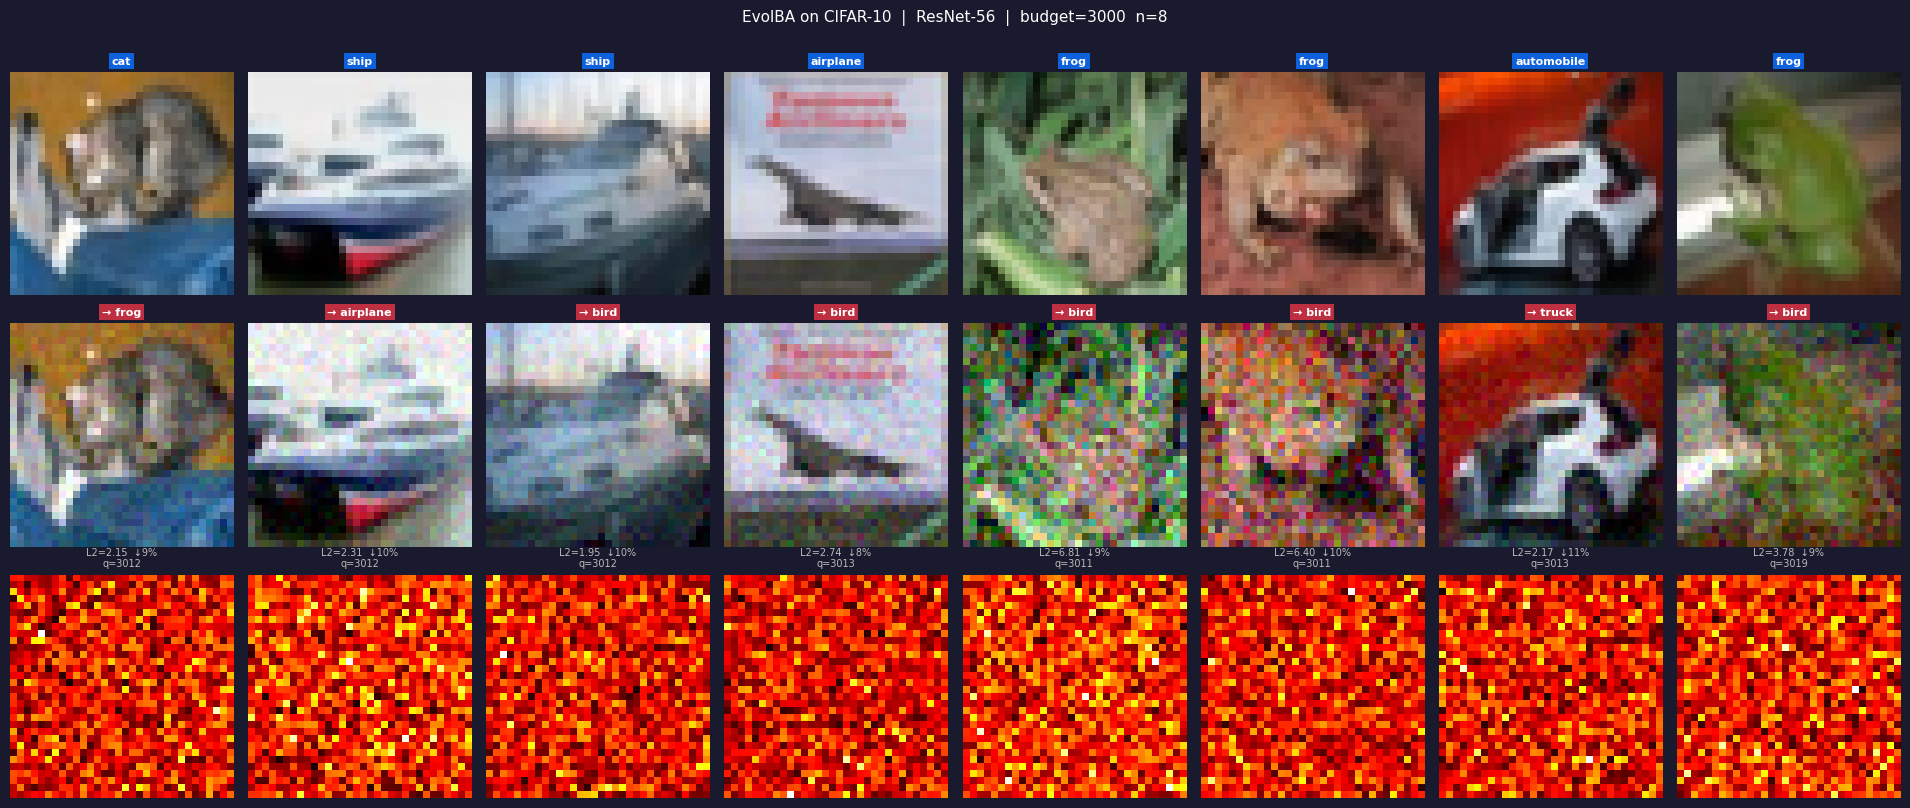

Saved → cifar10_adversarial_gallery.png


In [15]:
N_SHOW = min(8, len(successes))
show   = successes[:N_SHOW]

fig, axes = plt.subplots(3, N_SHOW, figsize=(2.4 * N_SHOW, 8))
fig.patch.set_facecolor('#1a1a2e')

for col, r in enumerate(show):
    orig    = r['image_hwc']
    adv     = r['best_adv']
    delta   = adv - orig
    mag     = np.linalg.norm(delta, axis=2)   # per-pixel L2 across channels
    tl      = CLASS_NAMES[r['true_label']]
    al      = CLASS_NAMES[r['adv_label']]

    axes[0, col].imshow(np.clip(orig, 0, 1), interpolation='nearest')
    axes[0, col].set_title(tl, fontsize=8, color='white', fontweight='bold',
                            bbox=dict(facecolor='#0d6efd', alpha=0.85, pad=2, edgecolor='none'))
    axes[0, col].axis('off')

    axes[1, col].imshow(np.clip(adv, 0, 1), interpolation='nearest')
    axes[1, col].set_title(f'\u2192 {al}', fontsize=8, color='white', fontweight='bold',
                            bbox=dict(facecolor='#dc3545', alpha=0.85, pad=2, edgecolor='none'))
    axes[1, col].axis('off')

    axes[2, col].imshow(mag, cmap='hot', vmin=0, interpolation='nearest')
    axes[2, col].set_title(
        f'L2={r["best_l2"]:.2f}  \u2193{r["l2_reduction"]:.0f}%\nq={r["queries"]}',
        fontsize=7, color='#bbbbbb'
    )
    axes[2, col].axis('off')

for row_i, lbl in enumerate(['Original', 'Adversarial', '\u0394 magnitude']):
    axes[row_i, 0].set_ylabel(lbl, fontsize=9, color='white', rotation=90, labelpad=6)

fig.suptitle(f'EvolBA on CIFAR-10  |  ResNet-56  |  budget={MAX_Q}  n={N_SHOW}',
             fontsize=11, color='white', y=1.01)
plt.tight_layout()
plt.savefig('cifar10_adversarial_gallery.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved \u2192 cifar10_adversarial_gallery.png')

### 8.2 L2 reduction: binary search → CMA-ES

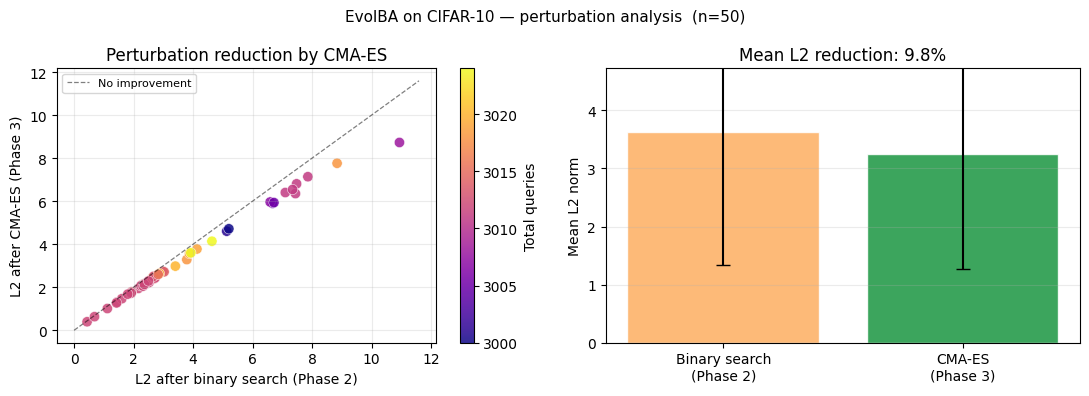

Saved → cifar10_l2_reduction.png


In [16]:
init_l2s  = [r['init_l2']      for r in successes]
final_l2s = [r['best_l2']      for r in successes]
queries_s = [r['queries']      for r in successes]
reduct_s  = [r['l2_reduction'] for r in successes]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sc  = axes[0].scatter(init_l2s, final_l2s, c=queries_s, cmap='plasma',
                      s=55, alpha=0.85, edgecolors='white', linewidths=0.4)
lim = max(max(init_l2s), max(final_l2s)) * 1.06
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=0.9, alpha=0.5, label='No improvement')
axes[0].set_xlabel('L2 after binary search (Phase 2)')
axes[0].set_ylabel('L2 after CMA-ES (Phase 3)')
axes[0].set_title('Perturbation reduction by CMA-ES')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)
fig.colorbar(sc, ax=axes[0], label='Total queries')

stages = ['Binary search\n(Phase 2)', 'CMA-ES\n(Phase 3)']
means  = [np.mean(init_l2s), np.mean(final_l2s)]
stds   = [np.std(init_l2s),  np.std(final_l2s)]
bars   = axes[1].bar(stages, means, yerr=stds,
                     color=['#fdae61', '#1a9641'],
                     alpha=0.85, capsize=5, edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', fontsize=9, padding=4)
axes[1].set_ylabel('Mean L2 norm')
axes[1].set_title(f'Mean L2 reduction: {np.mean(reduct_s):.1f}%')
axes[1].set_ylim(0, max(means) * 1.3)
axes[1].grid(axis='y', alpha=0.25)

fig.suptitle(f'EvolBA on CIFAR-10 — perturbation analysis  (n={len(successes)})', fontsize=11)
plt.tight_layout()
plt.savefig('cifar10_l2_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 cifar10_l2_reduction.png')

### 8.3 Query distribution and success rate vs budget

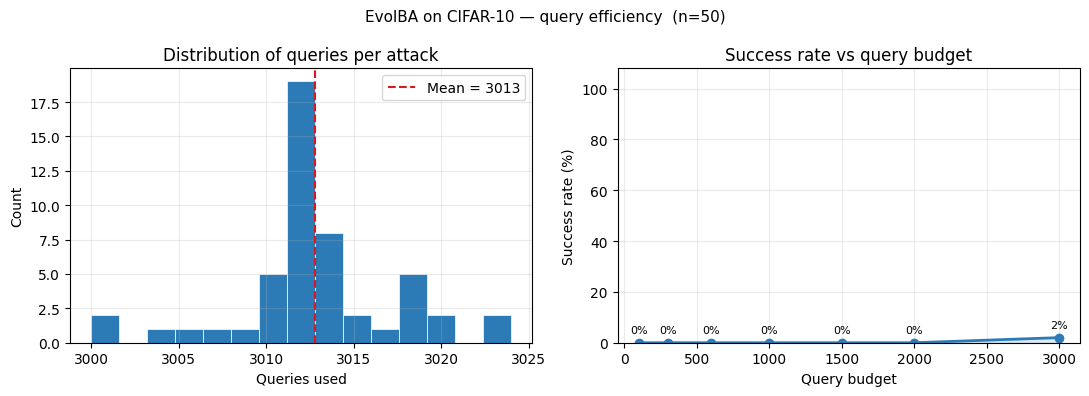

Saved → cifar10_query_stats.png


In [17]:
budgets = [100, 300, 600, 1000, 1500, 2000, MAX_Q]
sr_at   = [
    sum(1 for r in results if r['success'] and r['queries'] <= b) / N_EVAL * 100
    for b in budgets
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(queries_s, bins=15, color='#2c7bb6', edgecolor='white', linewidth=0.5)
axes[0].axvline(np.mean(queries_s), color='#d7191c', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(queries_s):.0f}')
axes[0].set_xlabel('Queries used')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of queries per attack')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(budgets, sr_at, 'o-', color='#2c7bb6', linewidth=2, markersize=6)
axes[1].fill_between(budgets, sr_at, alpha=0.15, color='#2c7bb6')
for b, sr in zip(budgets, sr_at):
    axes[1].annotate(f'{sr:.0f}%', (b, sr), textcoords='offset points',
                     xytext=(0, 7), ha='center', fontsize=8)
axes[1].set_xlabel('Query budget')
axes[1].set_ylabel('Success rate (%)')
axes[1].set_title('Success rate vs query budget')
axes[1].set_ylim(0, 108)
axes[1].grid(True, alpha=0.25)

fig.suptitle(f'EvolBA on CIFAR-10 — query efficiency  (n={N_EVAL})', fontsize=11)
plt.tight_layout()
plt.savefig('cifar10_query_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 cifar10_query_stats.png')